<a href="https://colab.research.google.com/github/LucasPeil/Air-Passengers/blob/main/Estudo_Air_Passangers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub[pandas-datasets]
!pip install pmdarima
!pip install openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sns
import statsmodels.tsa.stattools as tsa
from kagglehub import KaggleDatasetAdapter
from matplotlib.pylab import rcParams
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima.arima.utils import ndiffs, nsdiffs
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore') # Ignorar warnings para melhor leitura do output
rcParams['figure.figsize'] = 15,6

In [ ]:
# Importando dataset Air Passaengers
file_path = "AirPassengers.csv"
df = kagglehub.dataset_load(

  KaggleDatasetAdapter.PANDAS,
  "rakannimer/air-passengers",
  file_path
)
df.head(10)

#Definindo funcões estatísticas
def kpss_test (series, title=''):
  print(title)
  kpss_stat, p_value,lags, critical_values = tsa.kpss(series)

  print(f'Estatística do teste: {kpss_stat:.4f}')
  print(f'p-valor: {p_value:.4f}')
  print('Valores Críticos:')
  for key, value in critical_values.items():
      print(f'{key}: {value:.4f}')
  print('Resultado:')
  if p_value>0.05:
      print("Falha ao rejeitar a hipótese nula: A série é estacionária.")
  else:
      print("Rejeitamos a hipótese nula: A série NÃO é estacionária.")

def adfuller_test(series,title=''):
  print(title)
  df = tsa.adfuller(series)
  e, p_value = df[0], df[1]
  print("Estatística de teste: {:.4f}".format(e))
  print("p-valor: {:.8f}".format(p_value))
  print("Valores críticos:")
  for key,value in df[4].items():
    print("{} : {:.4f}\n". format(key,value))
  if p_value < 0.05:
    print("Rejeitamos a hipótese nula: A série é estacionária.")
  else:
    print("Falha ao rejeitar a hipótese nula: A série NÃO é estacionária.")

def shapiro_test(series, title=''):
  e,p_value = stats.shapiro(series)
  print(title)
  print("Estatística de teste: {:.4f}".format(e))
  print("p-valor: {:.8f}".format(p_value))
  if p_value < 0.05:
    print("Rejeitamos a hipótese nula: A série NÃO segue uma distribuição aproximadamente normal.")
  else:
    print("Falha ao rejeitar a hipótese nula: A série segue uma distribuição aproximadamente normal.")

def plot_acf_pacf(series, lags=25, title=''):
  fig, axes = plt.subplots(1,3, figsize=(18,5))
  axes[0].plot(series)
  axes[0].set_title(f'Série Temporal - {title}')
  plot_acf(series, lags=lags, ax=axes[1], title = f"Gráfico de Autocorrelação (ACF) - {title}")
  plot_pacf(series, lags=lags, ax=axes[2], title = f"Gráfico de Autocorrelação Parcial (PACF) - {title}")
  plt.tight_layout()
  plt.show()

def ljung_box_test(series, lags=20, title=''):
  print(title)
  ljung_box_result = sm.stats.acorr_ljungbox(series,lags=[min(40, len(series) - 1)], return_df=True)
  print(ljung_box_result)
  if ljung_box_result['lb_pvalue'].iloc[0] > 0.05:
    print("Falha ao rejeitar a hipótese nula: Não há autocorrelação significativa.")
  else:
    print("Rejeitamos a hipótese nula: Os resíduos não são independentes.")

def model_visual_analysis(model,title_correlation, title_qqplot):
  plot_acf_pacf(model, title=(title_correlation))
  plt.figure(figsize=(6, 4))
  stats.probplot(model, dist='norm', plot=plt)
  plt.title(title_qqplot)
  plt.grid(True)
  plt.show()


Using Colab cache for faster access to the 'air-passengers' dataset.


In [ ]:

df["Month"] =  pd.to_datetime(df['Month'], format='%Y-%m')
series = df.set_index('Month')
# Selecionando a coluna 'Passengers' e garantindo que é uma Série Pandas
series = series['#Passengers']
series.describe()

,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


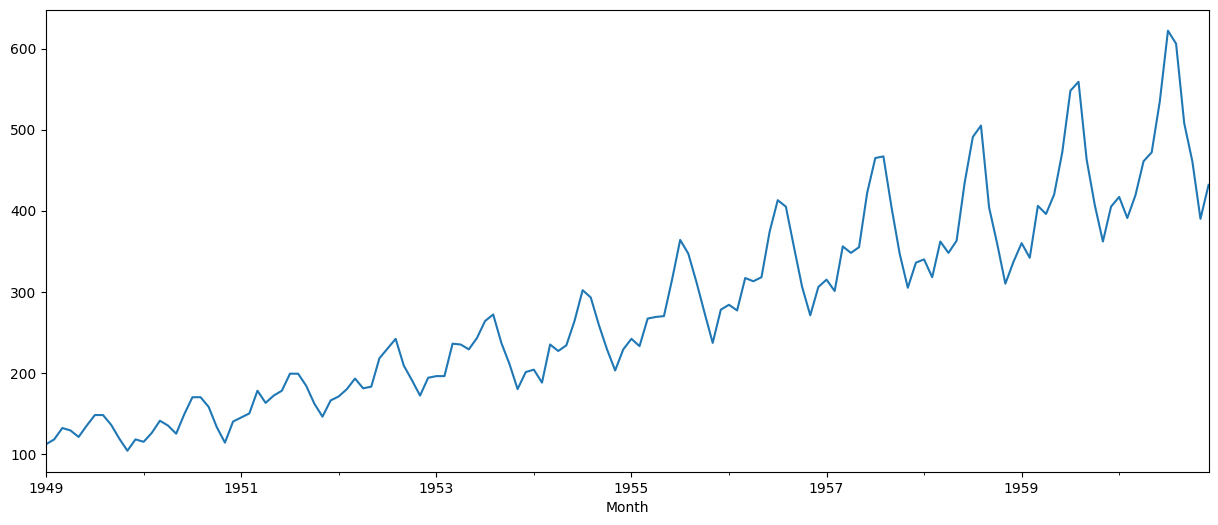

In [ ]:
series.plot()
plt.show()

Gráfico indica uma tendência clara e a presença de sazonalidade (picos regulares que aumentam ao decorrer dos anos)

***Verificando a normalidade dos dados***

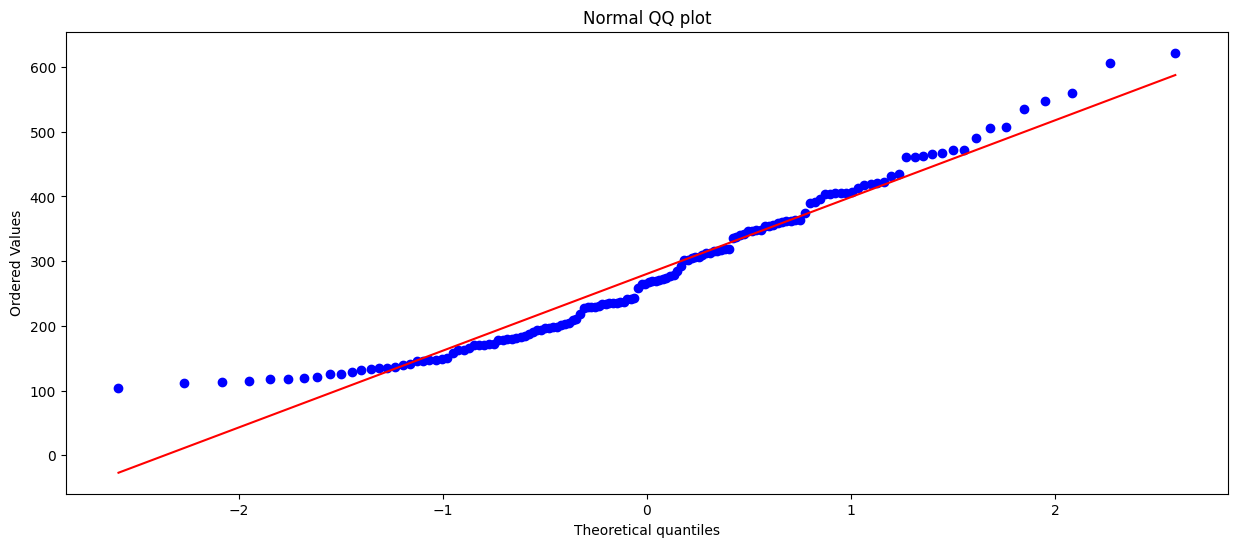

In [ ]:
stats.probplot(series, dist="norm", plot=plt)
plt.title("Normal QQ plot")
plt.show()

Séries demonstra problemas de normalidade no começo e ao final (onde se distancia da linha)

**Teste Shapiro-Wilk**

CRITÉRIOS:

NÍVEL DE SIGNIFICÂNCIA DE 0,05

* H0: A série segue uma distribuição aproximadamente normal QUANDO p > 0,05.
* Ha: A série NÃO segue uma distribuição aproximadamente normal QUANDO p < 0,05.

In [ ]:

shapiro_test(series)


Estatística de teste: 0.9520
p-valor: 0.00006832
Rejeitamos a hipótese nula: A série NÃO segue uma distribuição aproximadamente normal.


P-valor menor que 0,05, confirmando a **não** normalidade da distribuição

### Transformação logarítimca

Aplicando a transformação logarítica para diminuir a variância e melhorar a normalidade

In [ ]:
series_log = np.log(series)
series_log

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


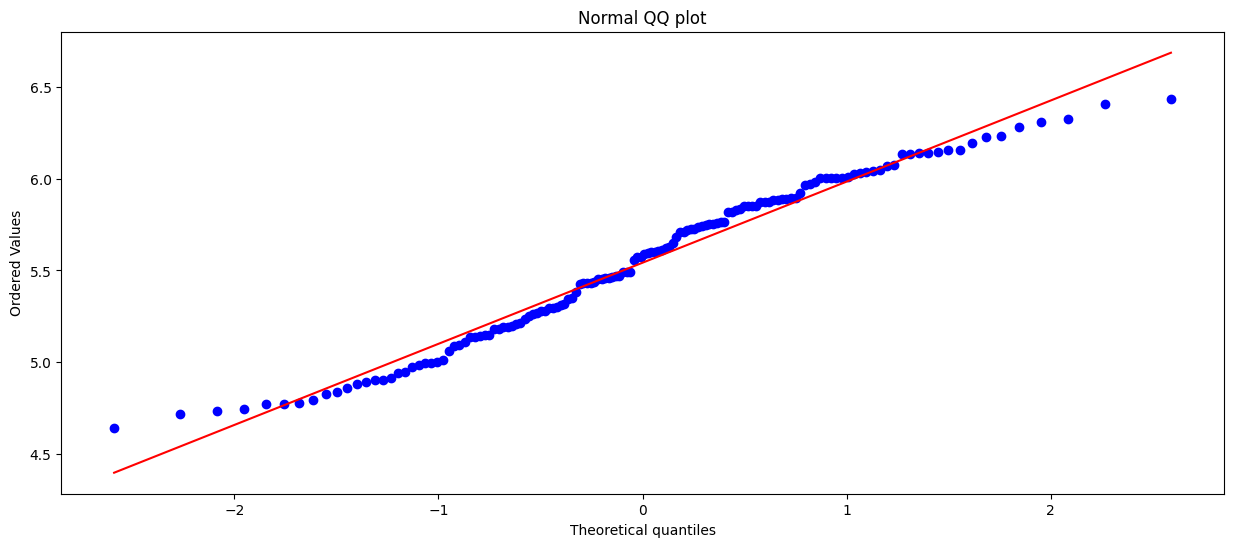

In [ ]:
stats.probplot(series_log, dist='norm', plot=plt)
plt.title('Normal QQ plot')
plt.show()


In [ ]:
e,p = stats.shapiro(series_log)
print(f"Estatística de teste: {e}\nP-valor: {p}")

Estatística de teste: 0.9732353614283915
P-valor: 0.00637340847572561


Apesar de ter havido uma melhoria na normalidade (evidenciado pelo aumento do p-valor), p-valor continua menor que 0,05, **não** caracterizando uma distruibuição normal

<Axes: xlabel='#Passengers', ylabel='Density'>

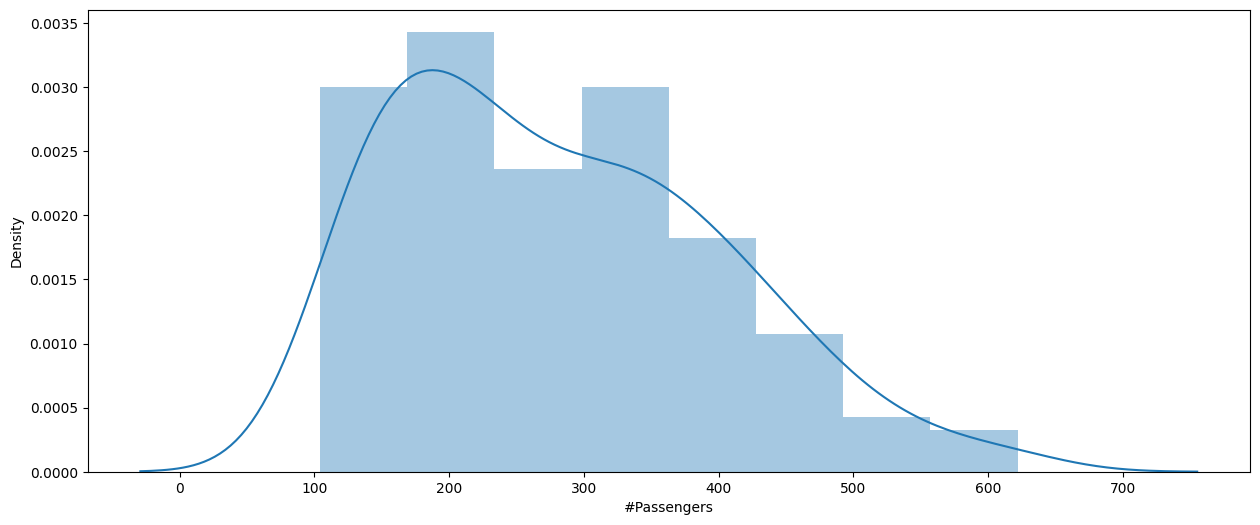

In [ ]:
sns.distplot(series)

<Axes: xlabel='#Passengers', ylabel='Count'>

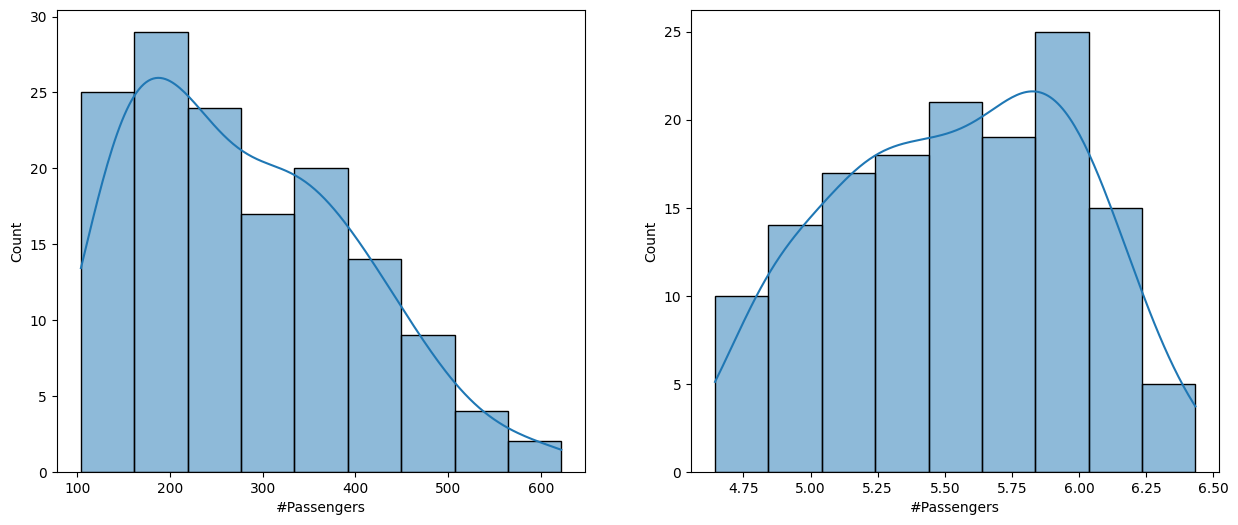

In [ ]:
fig, ax = plt.subplots(1,2)
sns.histplot(series, kde=True, ax=ax[0])
sns.histplot(series_log, kde=True, ax = ax[1])

**Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin)**

Ho = é estacionário: p-valor > 0,05

Ha = não é estacionário: p-valor < 0,05

In [ ]:
kpss_test(series_log)


Estatística do teste: 1.6687
p-valor: 0.0100
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Resultado:
Rejeitamos a hipótese nula: A série NÃO é estacionária.


p-valor menor que 0,05, indicando a não estacionaridade da série

**Teste df (Dickey Fuller)**

Ho = não é estacionário: estatística do teste >= valor crítico (p-valor > 0,05)

Ha = é estacionário: estatística do teste < valor crítico (p-valor < 0,05)

In [ ]:
adfuller_test(series_log)


Estatística de teste: -1.7170
p-valor: 0.42236677
Valores críticos:
1% : -3.4817

5% : -2.8840

10% : -2.5788

Falha ao rejeitar a hipótese nula: A série NÃO é estacionária.


A Estatística de teste e o p-valor do teste Dickey Fuller confirmam a não estacionaridade da série

### **DIFERENCIAÇÃO**
transformando uma série não estacionária em uma série estacionária

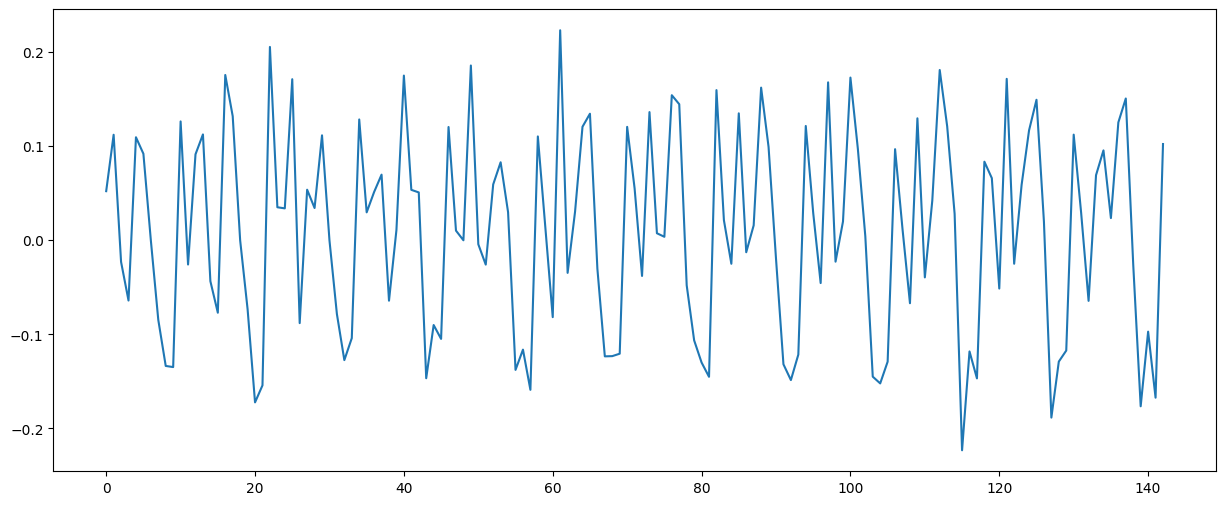

In [ ]:
series_diff = np.diff(series_log)
#Uma forma de fazer a diferenciação sem utilizar np.diff seria: series_diff = series_log - series_log.shift()
plt.plot(series_diff)
plt.show()

O gráfico indica uma possível estacionaridade da séries

Confirmando a Estacionaridade da série após a diferenciação com os testes **KPSS** e **Dickey Fuller**

#### Teste KPSS

In [ ]:
kpss_test(series_diff)


Estatística do teste: 0.0383
p-valor: 0.1000
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Resultado:
Falha ao rejeitar a hipótese nula: A série é estacionária.


p-valor > 0.05 indicando a estacionaridade da serie.

#### Teste Dickey Fuller

In [ ]:
adfuller_test(series_diff)


Estatística de teste: -2.7171
p-valor: 0.07112055
Valores críticos:
1% : -3.4825

5% : -2.8844

10% : -2.5790

Falha ao rejeitar a hipótese nula: A série NÃO é estacionária.


Teste Dickey Fuller não confirma a estacionaridade.

In [ ]:
# Aplicando uma segunda diferenciação para confirmar a estacionaridade da série
series_diff_2 = np.diff(series_diff)
#TESTE KPSS
print("TESTE KPSS")
kpss_test(series_diff_2)

#Espaçamento
print("\n **************** \n")

#TESTE Dickey Fuller
print("Teste Dickey Fuller")
adfuller_test(series_diff_2)


TESTE KPSS

Estatística do teste: 0.0596
p-valor: 0.1000
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Resultado:
Falha ao rejeitar a hipótese nula: A série é estacionária.

 **************** 

Teste Dickey Fuller

Estatística de teste: -8.1966
p-valor: 0.00000000
Valores críticos:
1% : -3.4825

5% : -2.8844

10% : -2.5790

Rejeitamos a hipótese nula: A série é estacionária.


Após a segunda diferenciação a serie indica ser estacionaria (sem tendência e sazonalidade)

#### Nova análise gráfica

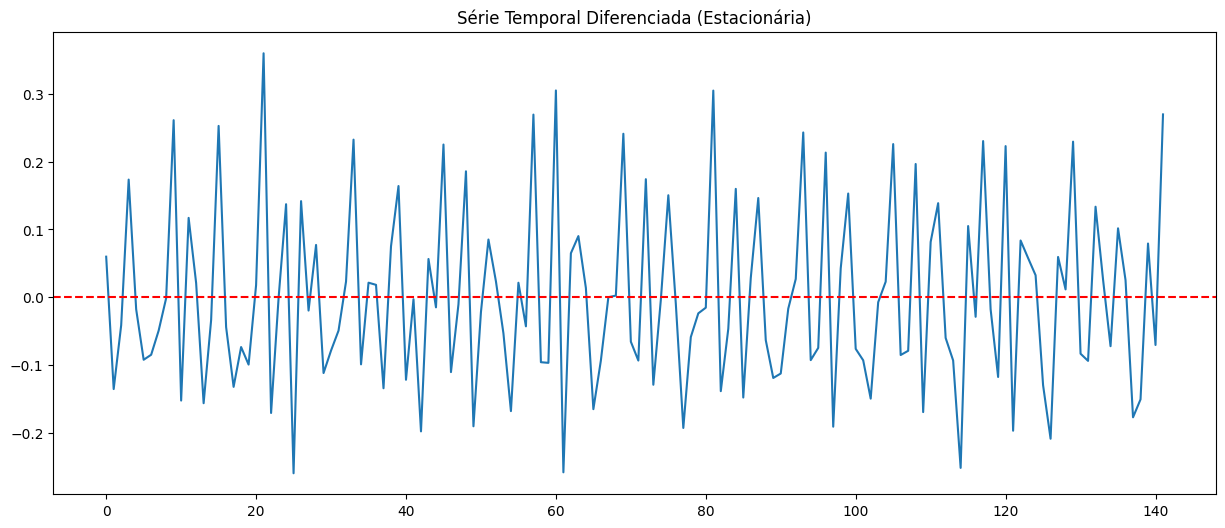

In [ ]:
plt.plot(series_diff_2)
plt.axhline(y=0,color="r",linestyle="--")
plt.title('Série Temporal Diferenciada (Estacionária)')
plt.show()

### IDENTIFICAÇÃO DOS PARÂMETROS DO MODELO (ACF e PACF)

Como já fizemos a transformação e a diferenciação da série temporal, transformando-a em uma série estacionária, podemos utilizar um modelo ARMA e posteriormente comparar com um modelo SARIMA

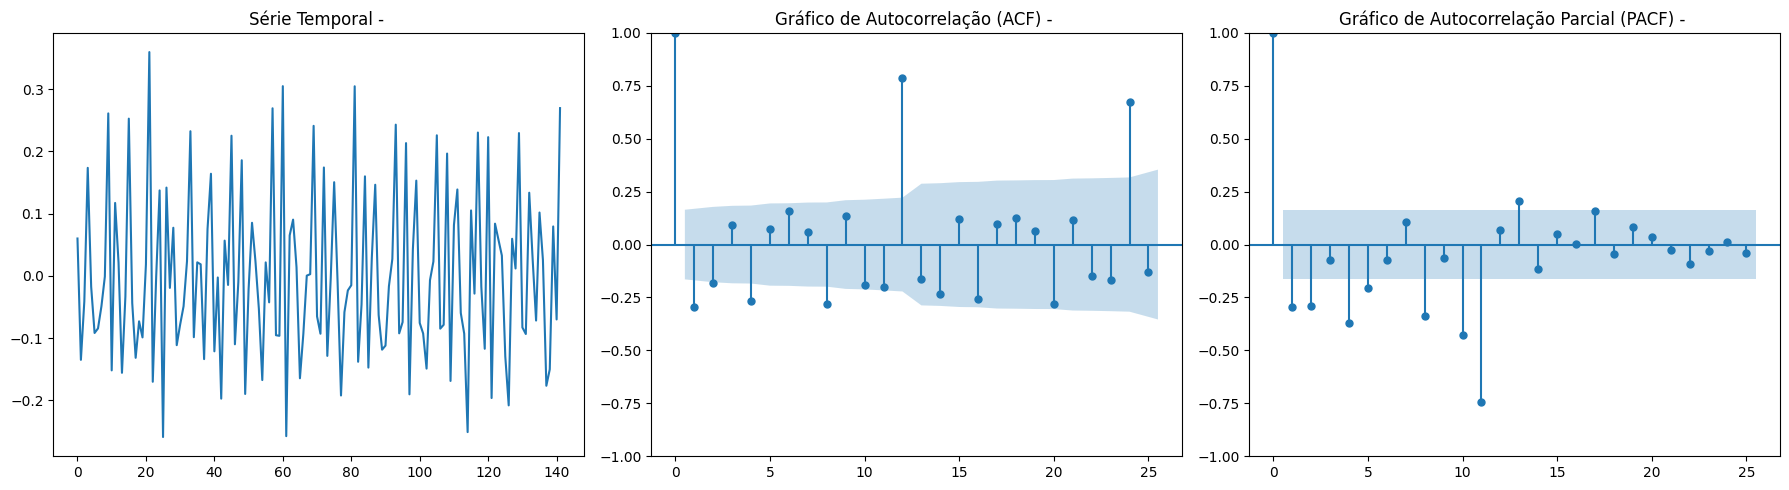

In [ ]:
plot_acf_pacf(series_diff_2, lags=25)


Após a análise dos gráficos ACF e PACF, podemos avaliar um Modelo ARMA de ordem p=1 e q=1. Como há picos significativos nos lags 12 e 24 no ACF e no lag 11 do gráfico PACF, é provável que o modelo ARMA não seja o suficiente, pois não foi possível eliminar completamente a sazonalidade.


In [ ]:
p,q = 1,1
ARMA_model = ARIMA(series_diff_2, order=(p,0,q)).fit()
E_ARMA = ARMA_model.resid
ARMA_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  142
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 117.144
Date:                Mon, 02 Mar 2026   AIC                           -226.288
Time:                        18:47:19   BIC                           -214.465
Sample:                             0   HQIC                          -221.484
                                - 142                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -8.78e-05      0.000     -0.274      0.784      -0.001       0.001
ar.L1          0.2070      0.116      1.777      0.075      -0.021       0.435
ma.L1         -0.9999     17.747     -0.056      0.955     -35.783      33.783
sigma2         0.0109      0.194      0.056      0.955      -0.369       0.390
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                 6.46
Prob(Q):                              0.73   Prob(JB):                         0.04
Heteroskedasticity (H):               1.17   Skew:                             0.23
Prob(H) (two-sided):                  0.59   Kurtosis:                         2.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Análise Gráfica dos Resíduos do Modelo ARIMA(1,0,1)


Os resíduos de um bom modelo de série temporal devem se assemelhar a ruído branco: não devem apresentar autocorrelação significativa e devem ser normalmente distribuídos. As plotagens ACF/PACF e o QQ-plot nos ajudarão a verificar isso.


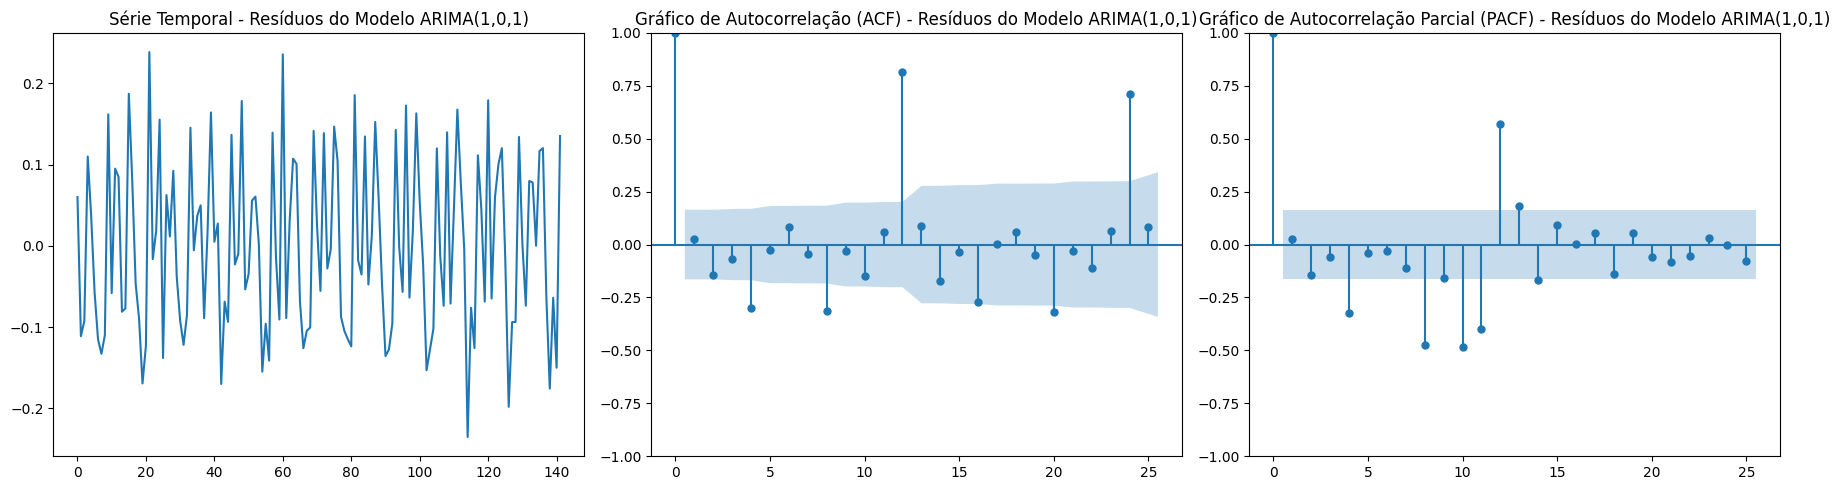

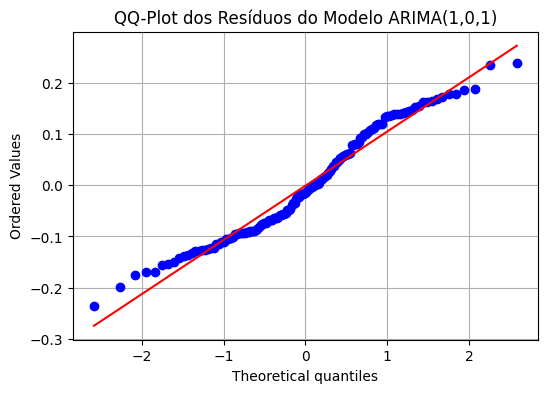

In [ ]:
model_visual_analysis(E_ARMA,title_correlation='Resíduos do Modelo ARIMA(1,0,1)', title_qqplot='QQ-Plot dos Resíduos do Modelo ARIMA(1,0,1)')

### Testes Estatísticos para Validar o Modelo ARIMA(1,0,1)

Para formalizar a avaliação dos resíduos, realizaremos os seguintes testes estatísticos:

#### Teste de Estacionaridade - KPSS para Resíduos


In [ ]:
kpss_test(E_ARMA)


Estatística do teste: 0.0357
p-valor: 0.1000
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Resultado:
Falha ao rejeitar a hipótese nula: A série é estacionária.


#### Teste de Independência - Ljung-Box
Verifica se as autocorrelações dos resíduos são significativamente diferentes de zero para vários lags.

-   **Hipótese Nula (H0)**: As autocorrelações dos resíduos são zero (os resíduos são ruído branco).
-   **Hipótese Alternativa (Ha)**: Pelo menos uma autocorrelação é diferente de zero (os resíduos não são ruído branco).

Um p-valor > 0.05 indica que não há evidências suficientes para rejeitar a hipótese nula, ou seja, os resíduos podem ser considerados ruído branco.


In [ ]:
ljung_box_test(E_ARMA, title='Resíduos do Modelo ARIMA(1,0,1)')

Resíduos do Modelo ARIMA(1,0,1)
       lb_stat     lb_pvalue
20  178.679235  1.759771e-27
Rejeitamos a hipótese nula: Os resíduos não são independentes.


#### Teste de Normalidade - Shapiro-Wilk

In [ ]:
shapiro_test(E_ARMA, title='Resíduos do Modelo ARIMA(1,0,1)')

Resíduos do Modelo ARIMA(1,0,1)
Estatística de teste: 0.9662
p-valor: 0.00141169
Rejeitamos a hipótese nula: A série NÃO segue uma distribuição aproximadamente normal.


Os resíduos não seguem uma distruibuição próxima a normal e não são independentes, o que indica que o modelo treinado não é o mais adequado

### UTILIZAÇÃO DE UM MODELO SARIMA COM A SÉRIE ORIGINAL

##Determinação de Ordens de Diferenciação


In [ ]:

print('Determinando a ordem de diferenciação não sazonal (d):')
d = ndiffs(series, test='kpss', max_d =5)
print(f'Número de diferenciações não sazonais necessárias (d): {d}')

print('\n Determinando a ordem de diferenciação sazonal (D):')
m = 12 # Período sazonal para dados mensais (12 meses)
D= nsdiffs(series,m=m, test="ocsb", max_D=3)
print(f'Número de diferenciações sazonais necessárias (D): {D}')


Determinando a ordem de diferenciação não sazonal (d):
Número de diferenciações não sazonais necessárias (d): 1

 Determinando a ordem de diferenciação sazonal (D):
Número de diferenciações sazonais necessárias (D): 1


Aplicando as Diferenciações e Análise da Série


ACF e PACF da Série Duplamente Diferenciada:


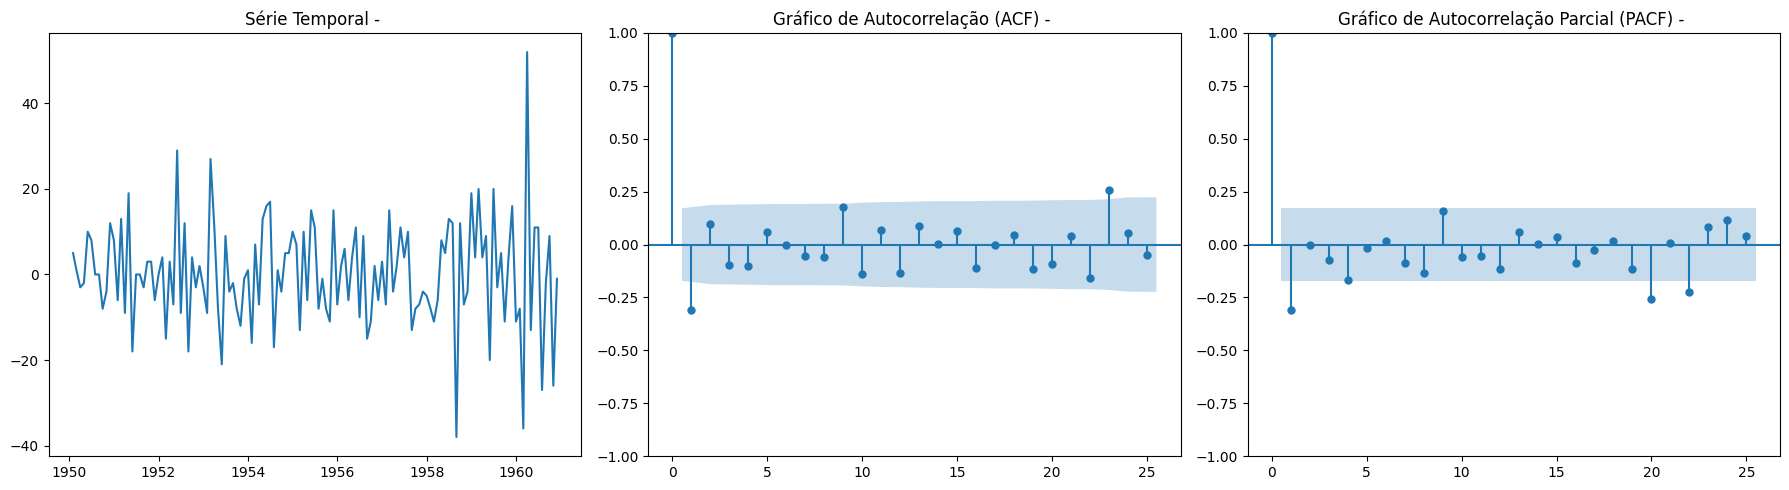

In [ ]:
new_series_diff = series.diff(d).dropna()
series_diff_season = new_series_diff.diff(m).dropna()
print('\nACF e PACF da Série Duplamente Diferenciada:')
plot_acf_pacf(series_diff_season, lags=25)

## Inicializando e treinando modelo SARIMA

In [ ]:
print("Ajustando modelo SARIMAX (1,1,0)(0,1,0)_12\n\n")

try:
  model1 = SARIMAX(series,order=(1,d,0),seasonal_order=(0,D,0,m), enforce_stationarity=False, enforce_invertibility=False).fit()
  E_model1 = model1.resid
  print("Resumo do modelo 1")
  print(model1.summary())
except Exception as e:
  print(f"Erro ao ajustar o Modelo 1: {e}")
  E_model1 = None

print("Ajustando modelo SARIMAX (1,1,1)(0,1,0)_12\n\n")
try:
  model2 = SARIMAX(series,order=(1,d,1),seasonal_order=(0,D,0,m), enforce_stationarity=False, enforce_invertibility=False).fit()
  E_model2 = model2.resid
  print("Resumo do modelo 2")
  print(model2.summary())
except Exception as e:
  print(f"Erro ao ajustar o Modelo 2: {e}")
  E_model2 = None

  print("Ajustando modelo SARIMAX (0,1,1)(0,1,1)_12\n\n")
try:
  model3 = SARIMAX(series,order=(0,d,1),seasonal_order=(0,D,1,m), enforce_stationarity=False, enforce_invertibility=False).fit()
  E_model3 = model3.resid
  print("Resumo do modelo 3")
  print(model3.summary())
except Exception as e:
  print(f"Erro ao ajustar o Modelo 3: {e}")
  E_model3 = None

Ajustando modelo SARIMAX (1,1,0)(0,1,0)_12


Resumo do modelo 1
                                     SARIMAX Results                                      
Dep. Variable:                        #Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 0)x(0, 1, 0, 12)   Log Likelihood                -504.684
Date:                            Mon, 02 Mar 2026   AIC                           1013.368
Time:                                    19:05:27   BIC                           1019.103
Sample:                                01-01-1949   HQIC                          1015.698
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3096      0.074     -4.190      0

### Análise Visual dos Resíduos do Modelo 1

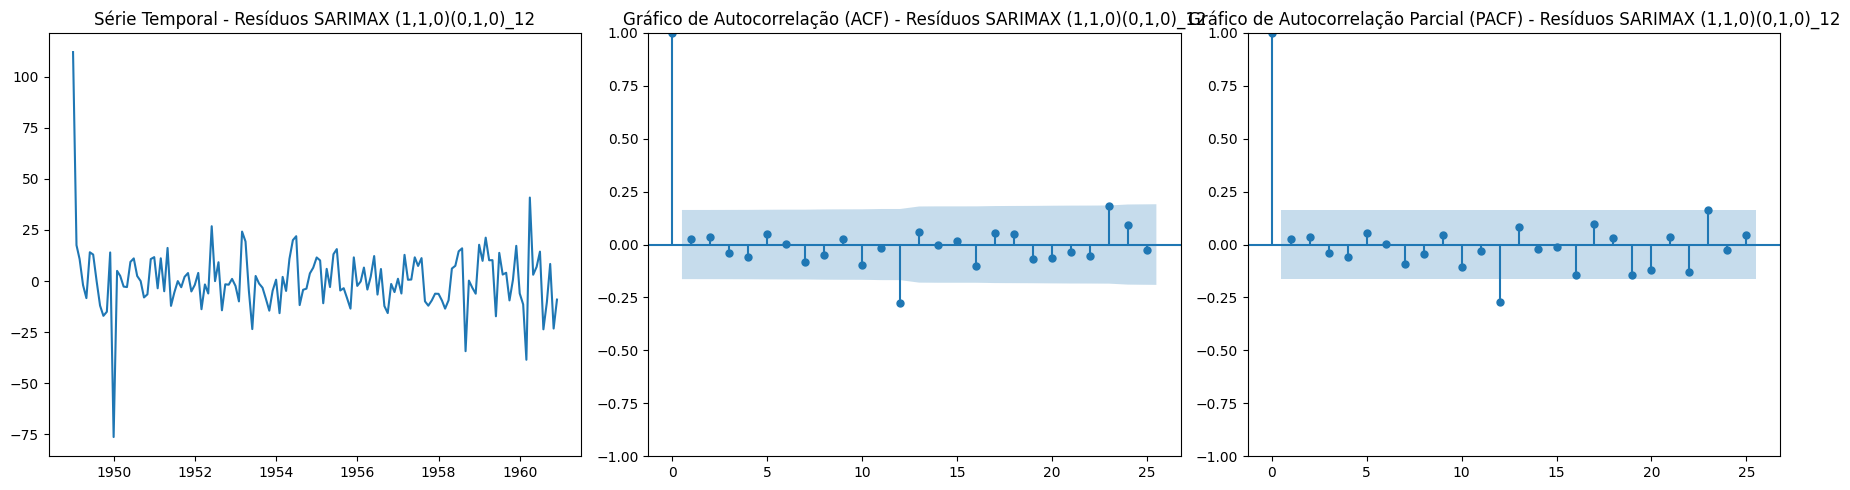

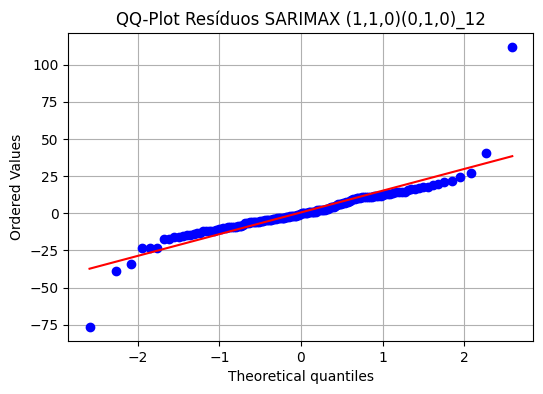

In [ ]:
model_visual_analysis(E_model1,title_correlation='Resíduos SARIMAX (1,1,0)(0,1,0)_12', title_qqplot='QQ-Plot Resíduos SARIMAX (1,1,0)(0,1,0)_12')

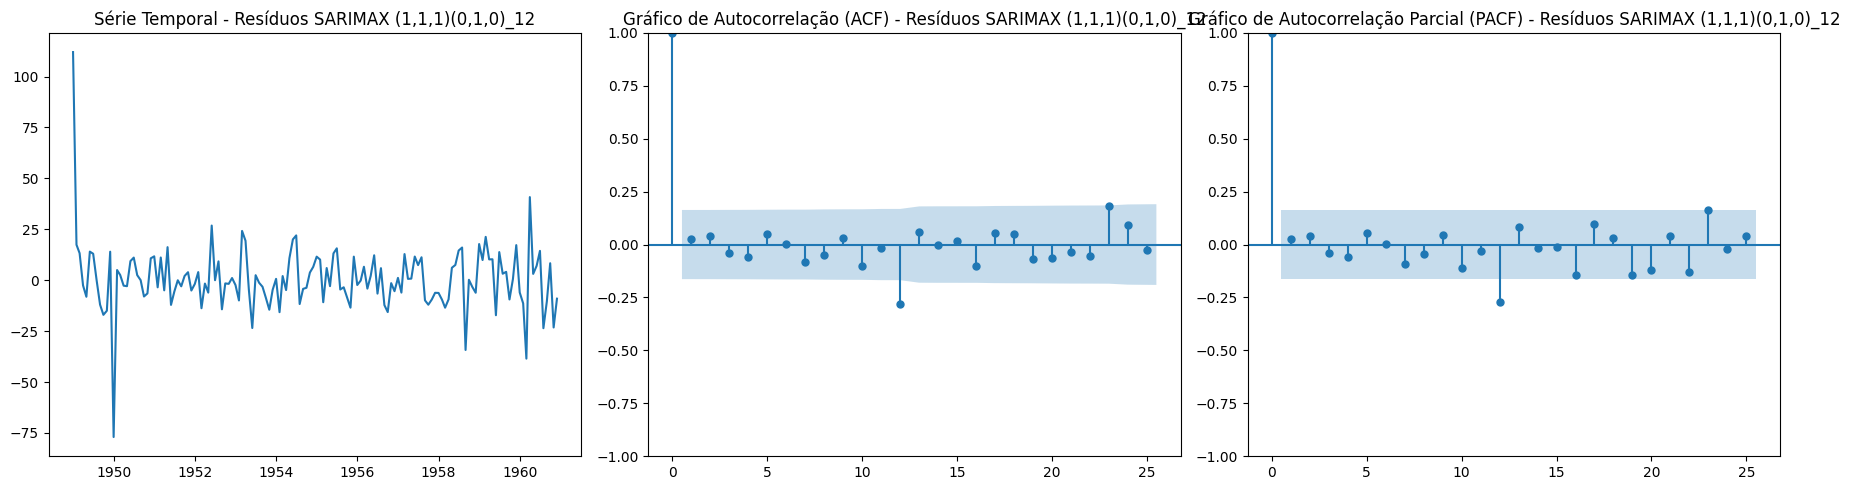

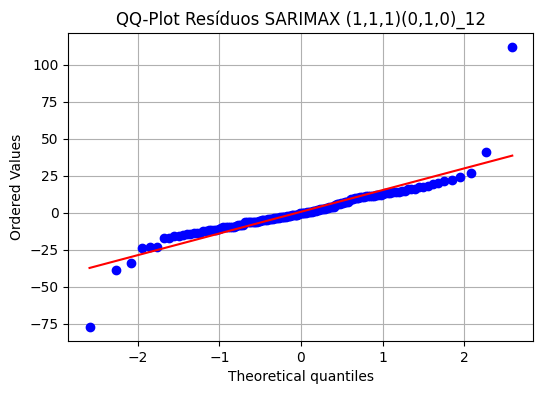

In [ ]:
model_visual_analysis(E_model2,title_correlation='Resíduos SARIMAX (1,1,1)(0,1,0)_12', title_qqplot='QQ-Plot Resíduos SARIMAX (1,1,1)(0,1,0)_12')

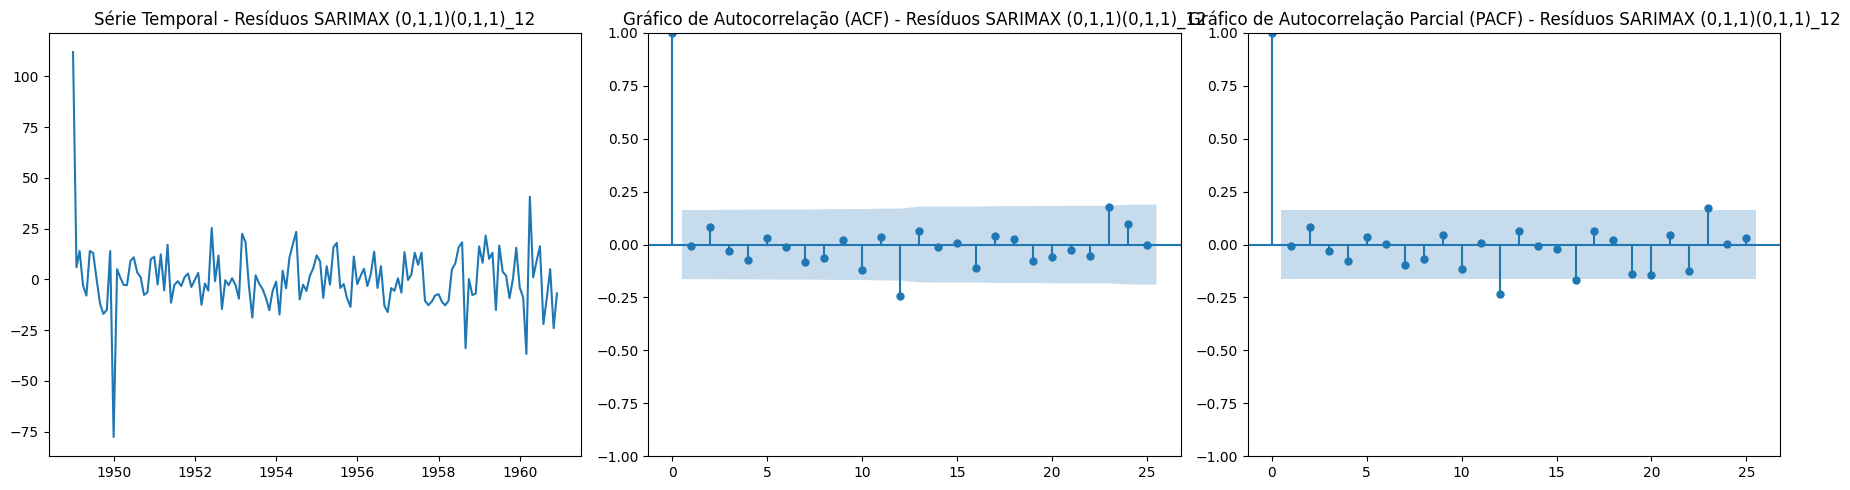

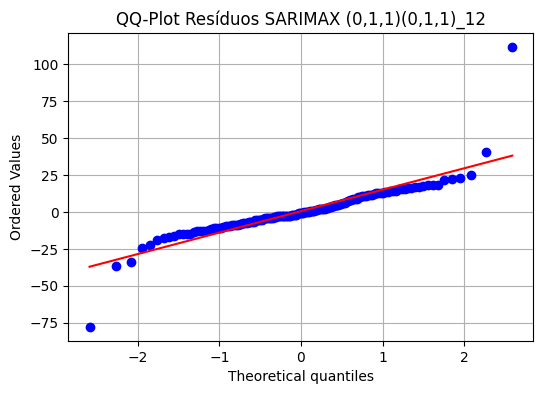

In [ ]:
model_visual_analysis(E_model3,title_correlation='Resíduos SARIMAX (0,1,1)(0,1,1)_12', title_qqplot='QQ-Plot Resíduos SARIMAX (0,1,1)(0,1,1)_12')

### Testes Estatísticos para Validar os modelos SARIMA


#### Teste de Estacionaridade - KPSS para Resíduos


In [ ]:
print("Teste Kpss resíduos modelo 1")
kpss_test(E_model1)
print("\nTeste Kpss resíduos modelo 2")
kpss_test(E_model2)
print("\nTeste Kpss resíduos modelo 3")
kpss_test(E_model3.dropna())

Teste Kpss resíduos modelo 1

Estatística do teste: 0.0968
p-valor: 0.1000
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Resultado:
Falha ao rejeitar a hipótese nula: A série é estacionária.

Teste Kpss resíduos modelo 2

Estatística do teste: 0.0986
p-valor: 0.1000
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Resultado:
Falha ao rejeitar a hipótese nula: A série é estacionária.

Teste Kpss resíduos modelo 3

Estatística do teste: 0.0803
p-valor: 0.1000
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Resultado:
Falha ao rejeitar a hipótese nula: A série é estacionária.


#### Teste de independência - Ljung-Box para Resíduos

In [ ]:
print("Teste Ljung-Box resíduos modelo 1")
ljung_box_test(E_model1)
print("\nTeste Ljung-Box resíduos modelo 2")
ljung_box_test(E_model2)
print("\nTeste Ljung-Box resíduos modelo 3")
ljung_box_test(E_model3)


Teste Ljung-Box resíduos modelo 1

      lb_stat  lb_pvalue
40  40.659608   0.441224
Falha ao rejeitar a hipótese nula: Não há autocorrelação significativa.

Teste Ljung-Box resíduos modelo 2

      lb_stat  lb_pvalue
40  40.924433   0.429734
Falha ao rejeitar a hipótese nula: Não há autocorrelação significativa.

Teste Ljung-Box resíduos modelo 3

      lb_stat  lb_pvalue
40  41.382145   0.410136
Falha ao rejeitar a hipótese nula: Não há autocorrelação significativa.


Teste de normalidade - Shapiro-Wilk para Resíduos

In [ ]:
print("Teste Shapiro-Wilk resíduos modelo 1")
shapiro_test(E_model1)
print("\nTeste Shapiro-Wilk resíduos modelo 2")
shapiro_test(E_model2)
print("\nTeste Shapiro-Wilk resíduos modelo 3")
shapiro_test(E_model3)

Teste Shapiro-Wilk resíduos modelo 1

Estatística de teste: 0.8072
p-valor: 0.00000000
Rejeitamos a hipótese nula: A série NÃO segue uma distribuição aproximadamente normal.

Teste Shapiro-Wilk resíduos modelo 2

Estatística de teste: 0.8069
p-valor: 0.00000000
Rejeitamos a hipótese nula: A série NÃO segue uma distribuição aproximadamente normal.

Teste Shapiro-Wilk resíduos modelo 3

Estatística de teste: 0.8021
p-valor: 0.00000000
Rejeitamos a hipótese nula: A série NÃO segue uma distribuição aproximadamente normal.


Dada a análise dos 3 modelos, o modelo 3 é o que apresenta a melhor performance.

Avaliando e fazendo previsões com o modelo SARIMAX (0,1,1)(0,1,1)_12

Métricas de Avaliação do Modelo:
MAE:16.09
RMSE:20.93
MAPE:3.62%


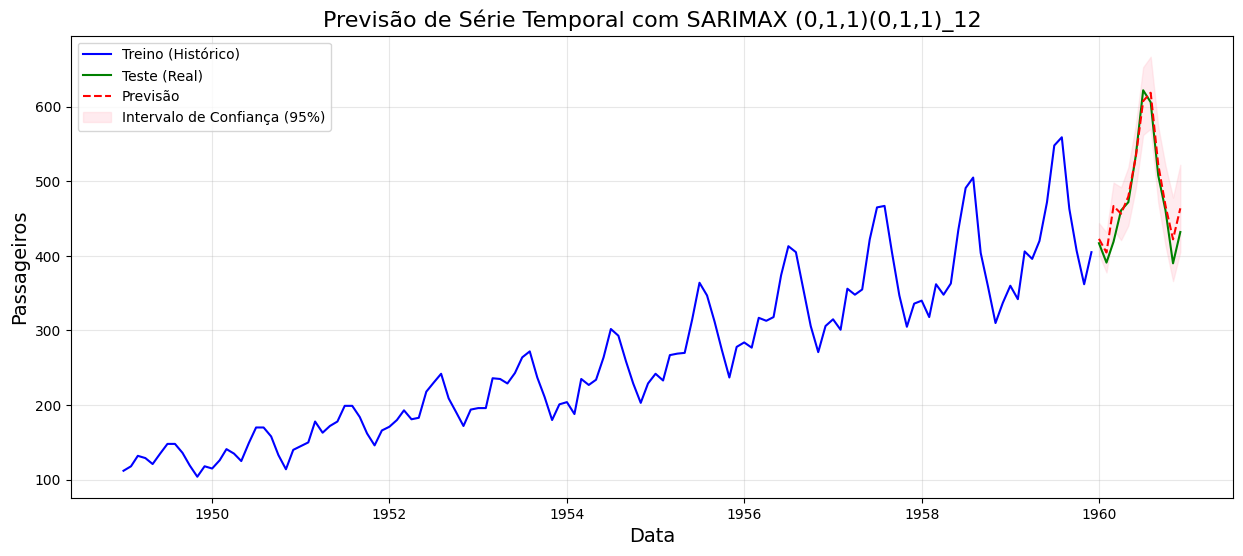


--- Tabela de Previsões ---
                Mês  Previsao Passageiros  Limite de erro Inferior  \
1960-01-01  1960-01                   423                      402   
1960-02-01  1960-02                   405                      378   
1960-03-01  1960-03                   467                      435   
1960-04-01  1960-04                   457                      421   
1960-05-01  1960-05                   480                      441   
1960-06-01  1960-06                   533                      491   
1960-07-01  1960-07                   608                      562   
1960-08-01  1960-08                   619                      570   
1960-09-01  1960-09                   523                      472   
1960-10-01  1960-10                   467                      414   
1960-11-01  1960-11                   422                      366   
1960-12-01  1960-12                   464                      405   

            Limite de erro Superior  
1960-01-01            

In [ ]:
train = series[:-12]
test = series[-12:]
best_model = SARIMAX(train, order=(0,1,1), seasonal_order=(0,1,1,12), enforce_stationarity=False, enforce_invertibility=False).fit()

# Gerando as Previsões
forecast_obj = best_model.get_forecast(steps=12)
forecast_mean = forecast_obj.predicted_mean
forecast_ci = forecast_obj.conf_int()

# Métricas de erro
mae = mean_absolute_error(test,forecast_mean)
rmse = np.sqrt(mean_squared_error(test,forecast_mean))
mape = np.mean(np.abs((test - forecast_mean)/test)) * 100

print("Métricas de Avaliação do Modelo:")
print(f"MAE:{mae:.2f}")
print(f"RMSE:{rmse:.2f}")
print(f"MAPE:{mape:.2f}%")

#Visualização dos Resultados
plt.figure(figsize=(15,6))
# Plotando dados reais
plt.plot(train.index, train, label="Treino (Histórico)", color="blue")
plt.plot(test.index, test, label="Teste (Real)", color="green")

# Plotando previsão
plt.plot(test.index,forecast_mean, label="Previsão", color="red", linestyle="--")


# Plotando intervalo de confiança

plt.fill_between(test.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color="pink", alpha=0.3, label="Intervalo de Confiança (95%)")

plt.title("Previsão de Série Temporal com SARIMAX (0,1,1)(0,1,1)_12", fontsize=16)
plt.xlabel("Data", fontsize=14)
plt.ylabel("Passageiros", fontsize=14)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

#Gerando a tabela final com as previsoes
df_forecast = pd.DataFrame({"Mês": forecast_mean.index.strftime("%Y-%m"), "Previsao Passageiros": forecast_mean.values.round(0).astype(int), "Limite de erro Inferior": forecast_ci.iloc[:,0].round(0).astype(int), "Limite de erro Superior": forecast_ci.iloc[:,1].round(0).astype(int)})

try:
  df_forecast.to_excel("Previões de passageiros para 1961.xlsx", index=False)
except Exception as e:
  print(f"Erro ao salvar o arquivo: {e}")

print("\n--- Tabela de Previsões ---")
print(df_forecast)



